# Homework 1: End-to-End Reconstruction with CNNs

This homework asks you to implement a compact **end-to-end reconstruction pipeline** using the ideas developed in the lecture. You will start from clean Mayo images, generate synthetic measurements with a known operator $K$, train simple neural networks with `MSELoss`, and compare the quality of the reconstructed images. The goal is not to build the strongest possible method, but to understand the full workflow and test a few basic design choices in a controlled setting.

You should submit the completed notebook together with a short written discussion of the final questions. Keep the code readable and add brief comments only where your implementation is not obvious.

## Tasks

Work through the notebook in order. In particular, you should:

1. build a dataset pipeline for the Mayo images;
2. generate measurements of the form
   $$
   y^\delta = Kx + e,
   $$
   where $K$ is a motion-blur operator and $e$ is additive Gaussian noise;
3. implement and train both a `SimpleCNN` and a `ResCNN`;
4. compare the two models visually and, if you wish, quantitatively;
5. answer the short conceptual questions at the end.

Use `nn.MSELoss()` and generate the corrupted data **online during training**. You may work on CPU, but a GPU is recommended if available.


In [7]:
import glob
import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

here = Path.cwd().resolve()
for base in (here, *here.parents):
    if (base / 'Mayo').exists():
        book_root = base
        break
else:
    raise FileNotFoundError('Could not locate the course root containing Mayo.')

for base in (here, here.parent):
    if (base / 'IPPy').exists():
        ippy_root = base / 'IPPy'
        break
else:
    raise FileNotFoundError('Could not locate the local IPPy package.')

operators_spec = importlib.util.spec_from_file_location('course_ippy_operators', ippy_root / 'operators.py')
operators = importlib.util.module_from_spec(operators_spec)
operators_spec.loader.exec_module(operators)


def get_device():
    if torch.cuda.is_available():
        return 'cuda'
    try:
        if torch.backends.mps.is_available():
            return 'mps'
    except AttributeError:
        pass
    return 'cpu'


def gaussian_noise(y, noise_level):
    e = torch.randn_like(y, device=y.device)
    return e / torch.norm(e) * torch.norm(y) * noise_level


device = get_device()
torch.manual_seed(0)
print('Working device:', device)


Working device: mps


## Implementation

Complete the code cells below. A good workflow is the following:

- first make sure the dataset and dataloaders work correctly;
- then define the motion blur operator and inspect one corrupted example;
- implement the two networks;
- train both models with the same settings;
- finally compare the reconstructions on a few test images.

Use `tqdm` to track training, inspect tensor shapes carefully, and keep the code close to the style used in the lecture notebook.


Batch tensor shape: (8, 1, 256, 256)
Batch dtype: torch.float32
Batch intensity range: 0.0 0.9370098114013672

Example image shape:  torch.Size([1, 256, 256])


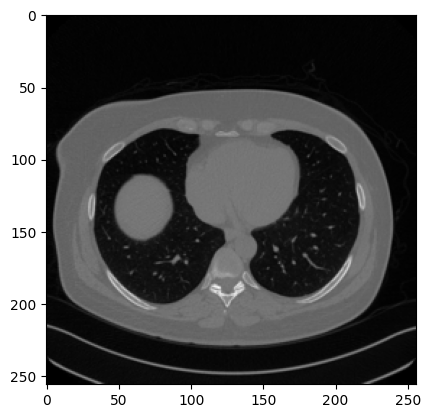

In [8]:
class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape):
        super().__init__()
        self.data_path = data_path
        self.data_shape = data_shape
        self.fname_list = glob.glob(f'{data_path}/*/*.png')

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        # 1. load the image from disk
        img_path = self.fname_list[idx]
       
        # 2. convert it to grayscale
        # 3. transform it into a tensor
        # 4. resize it to self.data_shape
        x = Image.open(img_path).convert('L')
        x = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(self.data_shape),
        ])(x)
         # 5. return the resulting tensor of shape (1, H, W)
        return x


# create train_dataset, test_dataset, train_loader, test_loader
# Suggested shape: 256
# Suggested batch size: 8
device = get_device()
train_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'train'), data_shape=256)
test_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'test'), data_shape=256)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


# inspect one training batch
batch = next(iter(train_loader))

# Print:
# - batch shape
# - dtype
# - min / max intensity
print('Batch tensor shape:', tuple(batch.shape))
print('Batch dtype:', batch.dtype)
print('Batch intensity range:', float(batch.min()), float(batch.max()))

# Then display one clean image from the batch.

example_image = train_dataset[0]
print('\nExample image shape: ', example_image.shape)

import matplotlib.pyplot as plt
plt.imshow(example_image.squeeze(), cmap='gray')
plt.show()

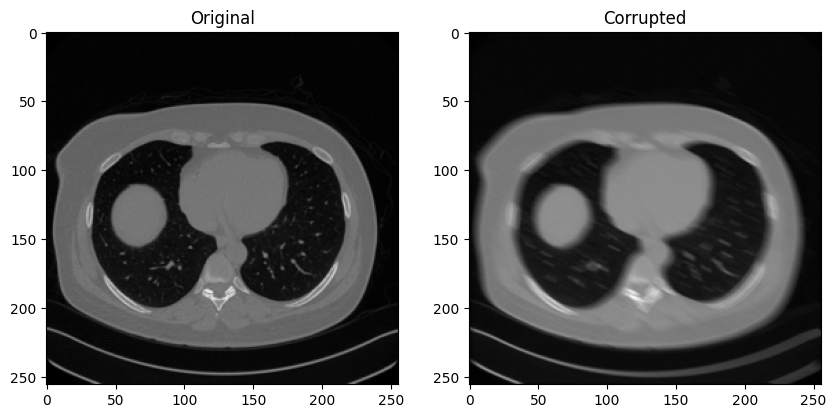

In [9]:
# Create operator
from IPPy import operators
from IPPy import utilities

# TODO:
# 1. define K = operators.Blurring(...)
K = operators.Blurring(
    img_shape=(256, 256),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

# How much noise how want to add
noise_level = 0.01

# 2. take one image x from the training loader
# 3. compute y_delta = K(x) + gaussian_noise(...)
with torch.no_grad():
    # Doesn't save the gradient (we don't need now and it's a heavy op)
    y = K(example_image)
    y_delta = y + gaussian_noise(y, noise_level)
# 4. visualize x and y_delta
# 4. visualizza x e y_delta
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(example_image.squeeze(), cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(y_delta.squeeze(), cmap='gray')
axes[1].set_title('Corrupted')
plt.show()


In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, n_filters=32, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding="same")

        self.relu = nn.ReLU()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        out = self.conv3(h)
        return out


class ResCNN(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, n_filters=32, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding="same")

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        out = self.tanh(self.conv3(h))
        return out + x


# 1. instantiate both models
simpleCNN_model = SimpleCNN(in_ch=1, out_ch=1, n_filters=32).to(device)
resCNN_model = ResCNN(in_ch=1, out_ch=1, n_filters=32).to(device)

# 2. print the number of trainable parameters of each model
simpleCNN_num_params = sum(p.numel() for p in simpleCNN_model.parameters() if p.requires_grad)
resCNN_num_params = sum(p.numel() for p in resCNN_model.parameters() if p.requires_grad)

print(f"Total trainable parameters of simpleCNN: {simpleCNN_num_params}")
print(f"Total trainable parameters of resCNN: {resCNN_num_params}")


Total trainable parameters of simpleCNN: 9857
Total trainable parameters of resCNN: 9857


--- SimpleCNN Training ---


Epoch 1/5:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/414 [00:00<?, ?it/s]

...

Epoch 2/5:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/414 [00:00<?, ?it/s]

Saved SimpleCNN weights to: /Users/mattia.dispigno/University/UniBo/computational imaging/Computational Imaging/weights/HM1_SimpleCNN.pth
Saved ResCNN weights to: /Users/mattia.dispigno/University/UniBo/computational imaging/Computational Imaging/weights/HM1_ResCNN.pth


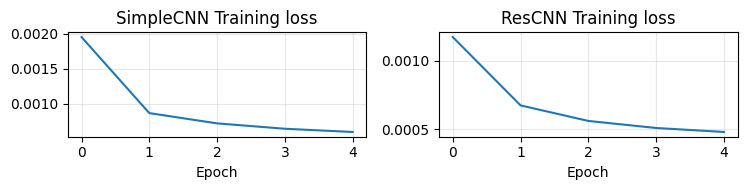

In [11]:

weights_dir = book_root / 'weights'
weights_dir.mkdir(exist_ok=True)

simpleCNN_weights_path = weights_dir / 'HM1_SimpleCNN.pth'
resCNN_weights_path = weights_dir / 'HM1_ResCNN.pth'

def train_model(model, train_loader, K, num_epochs=5, noise_level=0.01, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = []

    #print(f" --- {model} Training ---")
    # complete the training loop
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=True)

        for step, x_batch in enumerate(progress_bar, start=1):
            x_batch = x_batch.to(device)

            # - generate y_batch on the fly from x_batch
            with torch.no_grad():
                y_batch = K(x_batch)
                y_batch = y_batch + utilities.gaussian_noise(y_batch, noise_level=noise_level)

            prediction = model(y_batch)

            # - compute the loss
            loss = loss_fn(prediction, x_batch)

            # - perform backward + optimizer step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # - track the average epoch loss
            epoch_loss += loss.item()

            # - use tqdm for the batch loop
            progress_bar.set_postfix(batch_loss=f'{loss.item():.6f}', avg_loss=f'{epoch_loss / step:.6f}')

        history.append(epoch_loss / len(train_loader))
    
    return history


# 1. train both models
print('--- SimpleCNN Training ---')
simpleCNN_history = train_model(model=simpleCNN_model, train_loader=train_loader, K=K)

print('\n\n')
print('--- ResCNN Training ---')
resCNN_history = train_model(model=resCNN_model, train_loader=train_loader, K=K)

# 2. save the histories
torch.save(simpleCNN_model.state_dict(), simpleCNN_weights_path)
print(f'Saved SimpleCNN weights to: {simpleCNN_weights_path}')
torch.save(resCNN_model.state_dict(), resCNN_weights_path)
print(f'Saved ResCNN weights to: {resCNN_weights_path}')

# 3. plot the training curves together
plt.figure(figsize=(15, 2))
plt.subplot(1, 4, 1)
plt.plot(simpleCNN_history)
plt.title('SimpleCNN Training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)

plt.subplot(1, 4, 2)
plt.plot(resCNN_history)
plt.title('ResCNN Training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



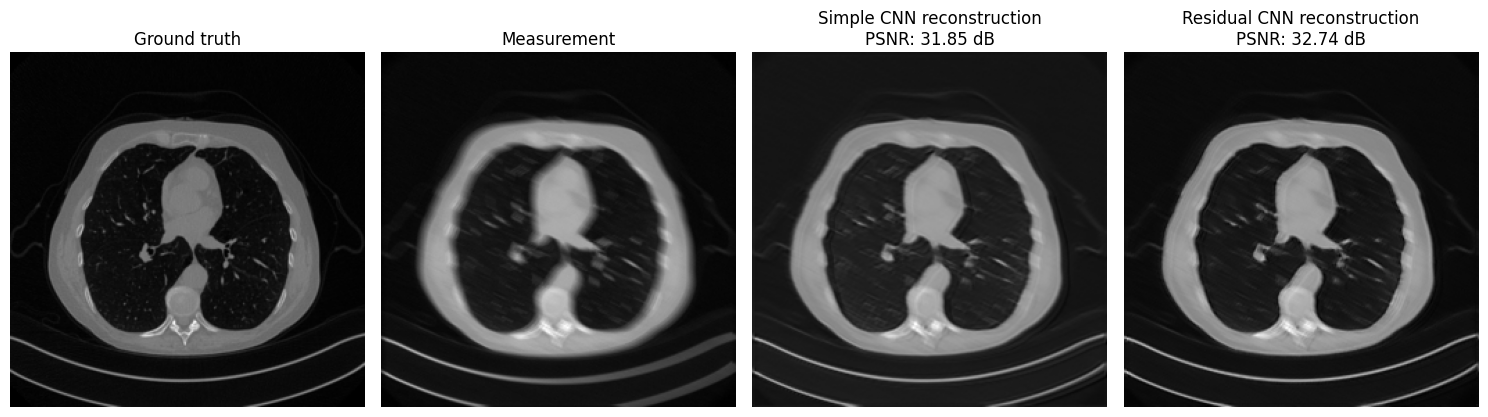

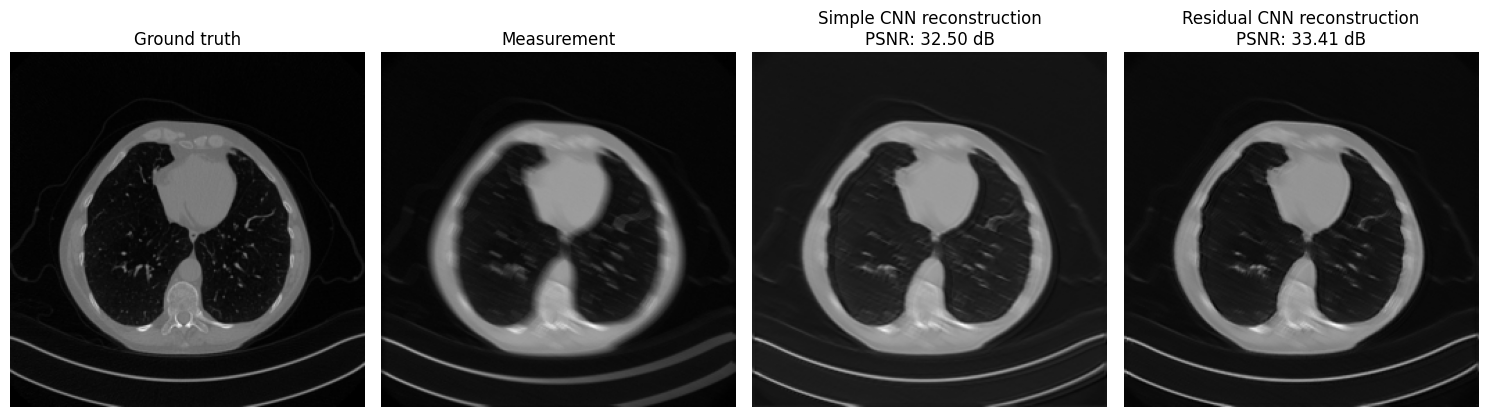

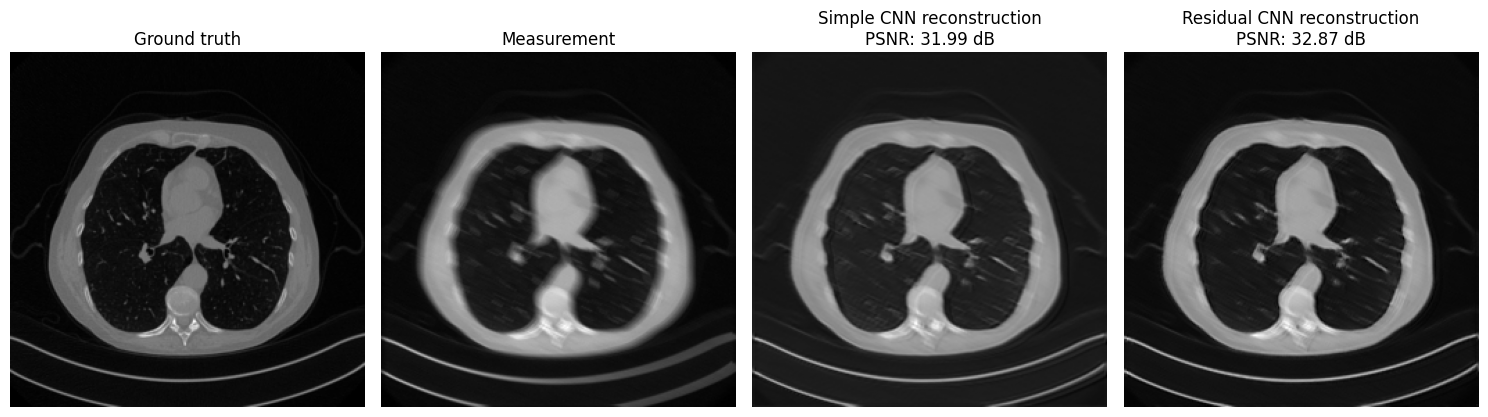

In [12]:
from IPPy.utilities.metrics import PSNR
# evaluate the two models on one or two test examples
# and visualize the results in a clean figure.
test_iter = iter(test_loader)

for i in range(3):
    with torch.no_grad():
        x_true = next(test_iter)[0:1].to(device)
        y_delta = K(x_true)
        y_delta = y_delta + gaussian_noise(y_delta, noise_level=noise_level)
        x_rec_simpleCNN = simpleCNN_model(y_delta)
        x_rec_resCNN = resCNN_model(y_delta)

    plt.figure(figsize=(15, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(x_true.cpu().squeeze(), cmap='gray')
    plt.title('Ground truth')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(y_delta.cpu().squeeze(), cmap='gray')
    plt.title('Measurement')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(x_rec_simpleCNN.cpu().squeeze(), cmap='gray')
    psnr_simple = float(PSNR(x_rec_simpleCNN, x_true))
    plt.title(f'Simple CNN reconstruction\nPSNR: {psnr_simple:.2f} dB')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(x_rec_resCNN.cpu().squeeze(), cmap='gray')
    psnr_res = float(PSNR(x_rec_resCNN, x_true))
    plt.title(f'Residual CNN reconstruction\nPSNR: {psnr_res:.2f} dB')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

## Discussion

Answer the following questions in a few sentences each.

1. Which model performed better in your experiments, and why do you think that happened?
2. Did the residual architecture help? If yes, in what sense?
3. How did the noise level affect training and reconstruction quality?
4. Why is it important to generate the corruption through a known operator $K$ instead of treating the problem as a generic image-to-image task?
5. Why should one be cautious when evaluating pure end-to-end methods only through visual quality?

If you want to go a little further, try one of the following extensions: replace `MSELoss` with `L1Loss`, change the blur strength, enlarge the number of filters, or compare training with and without added noise.


### Answers to Discussion Questions

1. **Which model performed better in your experiments, and why do you think that happened?**  
   The Residual CNN (ResCNN) typically performs better than the Simple CNN. This happens because the residual connection allows the network to learn only the high-frequency residual (the missing details and noise) instead of forcing it to reconstruct the entire image from scratch. This leads to an easier optimization landscape, preventing vanishing gradients and improving detail recovery.

2. **Did the residual architecture help? If yes, in what sense?**  
   Yes, the residual architecture was very helpful. It allowed for faster convergence during training and achieved higher reconstruction quality (higher PSNR). In a practical sense, it resulted in sharper images with better-preserved structures compared to the Simple CNN, which tends to produce blurrier outputs.

3. **How did the noise level affect training and reconstruction quality?**  
   Higher noise levels make the inversion problem more ill-posed, leading to a harder training process. The network has to balance between smoothing out the noise and preserving sharp edges. As a result, higher noise levels generally lead to lower final reconstruction quality and slightly over-smoothed details.

4. **Why is it important to generate the corruption through a known operator $K$ instead of treating the problem as a generic image-to-image task?**  
   Using a known forward operator $K$ embeds the actual physical properties of the measurement process (such as a specific blur kernel, in this case) into the training data. This ensures the network explicitly learns to invert the underlying physical degradation rather than just learning arbitrary, generic image-to-image mappings, which significantly improves robustness and generalizability to real-world measurements.

5. **Why should one be cautious when evaluating pure end-to-end methods only through visual quality?**  
   End-to-end neural networks are highly expressive and can sometimes hallucinate realistic-looking but physically incorrect details to make the image look visually pleasing. In critical applications like medical imaging, these hallucinations can lead to incorrect diagnoses. Therefore, visual quality must be complemented with quantitative metrics (like PSNR, SSIM) and data consistency checks.
